<a href="https://colab.research.google.com/github/LanqingDu/AdvancedBusinessAnalytics/blob/main/NB_5_Convolutional_Neural_Networks.ipynb" target="_blank">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# **CNN**



> **Instructor:** Dr. Lanqing Du  
> **Acknowledgement:** Based on [Python manuals](https://docs.python.org/3/), [Automate the Boring Stuff with Python, 2nd Edition: Practical Programming for Total Beginners](https://automatetheboringstuff.com/2e/), [TensorFlow](https://www.tensorflow.org/tutorials/images/cnn) and other data Science online sources.  
> **Objective:** Introduction to convolution neural networks.  
> **Instructions:** You can preview the **Table of Contents** from the side bar.

> **Disclaimer**: This notebook is prepared for instructional purposes. Some code blocks may intentionally contain errors to support the learning objectives.

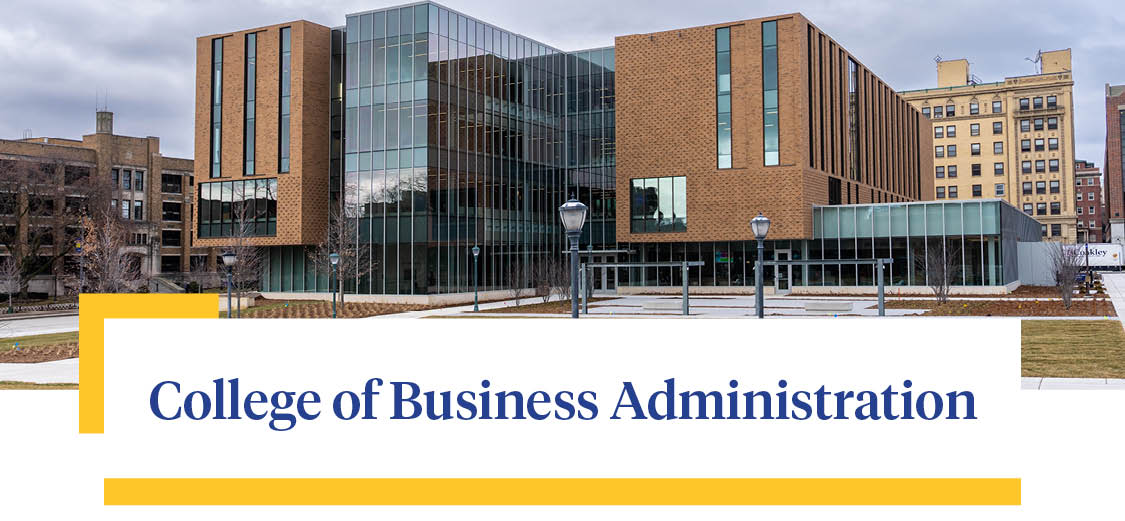
---

---

## [0. Agenda for Pandas](#Intro)

## 1. Pretrained Model

- **Loading**: Importing CIFAR 10 image data.
- **Pretrained Model**: Customized layer on top of EfficientNetB0.

## 2. Data Preprocessing

- **Data Augmentation**: Data techniques applied to image data.



---

## [1. Preparation](#S1)

- **Library Inclusion**: Importing essential frameworks including tensorflow, numpy, and matplotlib.- **TensorBoard Setup**: Initializing the magic command %load_ext tensorboard and creating a log directory for visualization.
- **Data Acquisition**: Loading the dataset and splitting it into distinct Training and Testing sets.
- **Image Preprocessing**:
  - Normalization: Dividing pixel values by 255 to scale data from $[0, 255]$ to $[0, 1]$.
  - Why 255? Neural networks converge faster when input features are on a similar small scale, preventing gradients from exploding.
  - Data Exploration: Inspecting the shape of the tensors and visualizing sample images to understand class distribution.

In [ ]:
# step 0: include libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import datetime
%matplotlib inline
%load_ext tensorboard

In [ ]:
# step 1: Setting up log folders for TensorBoard.

# Clear any logs from previous runs
!rm -rf ./logs/

# Define the Keras TensorBoard callback.
logdir="logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [ ]:
# step 2: Training and testing dataset from cifar10

# ======================TODO BELOW========================
# load cifar10 data
# fill in the <...>

(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.<...>.<...>

# ======================TODO ABOVE========================

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [ ]:
# step 3: image data preprocessing

train_images = train_images / 255
test_images = test_images / 255

In [ ]:
# step 4: check the shapes

# ======================TODO BELOW========================
# fill in the <...>

# check the training data (image shape)
print(<...>)

# check the training data (label)
print(train_labels.shape)

# check the testing data (image shape)
print(test_images.shape)

# check the testing data (label)
print(test_labels.shape)

# ======================TODO ABOVE========================

In [ ]:
# step 5: CIFAR class_names

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

<p>Here is how this dataset looks like:</p>
<table>
    <tbody><tr>
        <td>airplane</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane5.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane6.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane7.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane8.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane9.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane10.png"></td>
    </tr>
    <tr>
        <td>automobile</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/automobile1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/automobile2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/automobile3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/automobile4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/automobile5.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/automobile6.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/automobile7.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/automobile8.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/automobile9.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/automobile10.png"></td>
    </tr>
    <tr>
        <td>bird</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/bird1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/bird2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/bird3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/bird4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/bird5.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/bird6.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/bird7.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/bird8.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/bird9.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/bird10.png"></td>
    </tr>
    <tr>
        <td>cat</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/cat1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/cat2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/cat3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/cat4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/cat5.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/cat6.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/cat7.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/cat8.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/cat9.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/cat10.png"></td>
    </tr>
    <tr>
        <td>deer</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/deer1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/deer2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/deer3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/deer4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/deer5.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/deer6.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/deer7.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/deer8.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/deer9.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/deer10.png"></td>
    </tr>
    <tr>
        <td>dog</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/dog1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/dog2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/dog3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/dog4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/dog5.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/dog6.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/dog7.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/dog8.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/dog9.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/dog10.png"></td>
    </tr>
    <tr>
        <td>frog</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/frog1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/frog2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/frog3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/frog4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/frog5.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/frog6.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/frog7.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/frog8.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/frog9.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/frog10.png"></td>
    </tr>
    <tr>
        <td>horse</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/horse1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/horse2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/horse3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/horse4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/horse5.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/horse6.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/horse7.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/horse8.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/horse9.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/horse10.png"></td>
    </tr>
    <tr>
        <td>ship</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/ship1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/ship2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/ship3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/ship4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/ship5.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/ship6.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/ship7.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/ship8.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/ship9.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/ship10.png"></td>
    </tr>
    <tr>
        <td>truck</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/truck1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/truck2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/truck3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/truck4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/truck5.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/truck6.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/truck7.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/truck8.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/truck9.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/truck10.png"></td>
    </tr>
</tbody></table>

---

## [2. Customized Pretrained Layer](#S2)

- **Extra Layers:** Add extra layer on top of pretrained model.
To do so, we just extend the pretrained model by adding more layers to it.



In [ ]:
# step 6: load pretrained backbone (for example EfficientNet)


base_model = tf.keras.applications.EfficientNetB0(
    include_top = False,
    weights = "imagenet",
    input_shape = (32, 32, 3)
)

base_model.trainable = False # freeze for initial training

full_model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(32, 32, 3)),

    # Lambda wrapper layer
    tf.keras.layers.Lambda(
        # EfficientNet expects inputs preprocessed with its own preprocess_input
        tf.keras.applications.efficientnet.preprocess_input
    ),
    base_model,

    # add one extra dense layer with 64 neuron, relu activation function, and 30% dropout rate
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    # add the output layer
    tf.keras.layers.Dense(10)
])

In [ ]:
# step 7: model training and evaluation

full_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

full_model.summary()

full_model.fit(
    train_images, train_labels,
    epochs=4,
    validation_split=0.2
)

loss, acc = full_model.evaluate(test_images, test_labels)

**TODO**: Interpretation of the accuracy function.

---

## [3. Data Preprocessing](#S2)

- **Data Preprocessing:** When using a pretrained model, it is important to consider the dataset and input configuration used during pretraining. Since EfficientNet is typically trained on ImageNet with 224×224 images, resizing and proper preprocessing are often required to obtain optimal performance.

- **Data augmentation** (random transformations applied only during training) techniques:

  * Rotate each image randomly -40 to 40 degrees
  * Shift each image 0% to 20% vertically or horizontally
  * Shear each image by up to 20%
  * Zoom each image by up to 20%
  * Randomly flip each image horizontally or vertically
  * Fill in any missing pixels after a shift or shear with nearest neighbors

  In this notebook, we will work with a different image data, but could be applied to the above architecture for better performance (leave this part for student to explore ⛳)

In [ ]:
# step 8: include necessary libraries

from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# step 9: download the image dataset (Rock-Paper-Scissors image dataset)

!gdown --id 1tuMKLvmr0z1kQpCJYfX5SmYDOqHYeMrm

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1tuMKLvmr0z1kQpCJYfX5SmYDOqHYeMrm
From (redirected): https://drive.google.com/uc?id=1tuMKLvmr0z1kQpCJYfX5SmYDOqHYeMrm&confirm=t&uuid=74ecd5e0-cc50-4034-9cfb-29e0b63565f0
To: /content/rps.zip
100% 237M/237M [00:04<00:00, 54.2MB/s]


In [ ]:
# step 10: unzip the dataset

import os
import zipfile

zip_ref = zipfile.ZipFile('rps.zip', 'r')
zip_ref.extractall()
zip_ref.close()

In [ ]:
# step 11: check folder

print(os.listdir())

['.config', 'rps.zip', 'rps', 'sample_data']


In [ ]:
# step 12: check subfolder

print(os.listdir("rps"))

['train', 'validation', 'test']


Class: paper
Image path: rps/train/paper/paper01-000.png
Image shape: (300, 300)


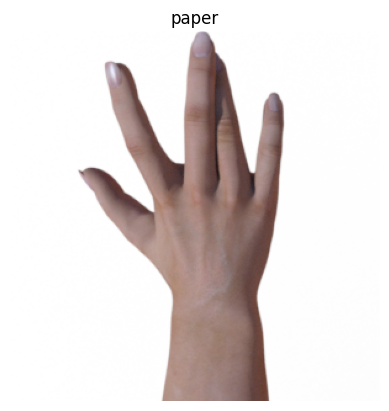

In [ ]:
# step 13: data exploration

from tensorflow.keras.utils import load_img
from PIL import Image

base_dir = "rps/train"

# First class (alphabetically)
first_class = sorted(os.listdir(base_dir))[0]
class_path = os.path.join(base_dir, first_class)

# First image inside that class
first_image = sorted(os.listdir(class_path))[0]
image_path = os.path.join(class_path, first_image)

print("Class:", first_class)
print("Image path:", image_path)

img = Image.open(image_path)
print("Image shape:", img.size)

# Load and display

plt.imshow(img)
plt.title(first_class)
plt.axis("off")
plt.show()

In [ ]:
|# step 14: training data augmentation

# ImageDataGenerator() is a Keras utility that applies preprocessing

training_datagen = ImageDataGenerator(
      rescale = 1./255,
	    rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

In [ ]:
# step 15: testing data augmentation

validation_datagen = ImageDataGenerator(rescale = 1./255)

In [ ]:
# step 16: training

# training_datagen.flow_from_directory() a method that actually loads images from folders and applies the augmentation settings

train_generator = training_datagen.flow_from_directory(
	'rps/train/',
	target_size=(150,150),
	class_mode='categorical'
)

Found 2520 images belonging to 3 classes.


In [ ]:
# step 17: validation

validation_generator = validation_datagen.flow_from_directory(
	'rps/validation/',
	target_size=(150,150),
	class_mode='categorical'
)

Found 33 images belonging to 3 classes.


In [ ]:
# step 18: test

test_generator = validation_datagen.flow_from_directory(
	'rps/test/',
	target_size=(150,150),
	class_mode='categorical'
)

Found 372 images belonging to 3 classes.


In [ ]:
# step 19: full model

model = tf.keras.models.Sequential([
    # Note the input shape is the desired size of the image 150x150 with 3 bytes color
    # This is the first convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    # The second convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The third convolution
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The fourth convolution
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(3)
])

model.compile(optimizer='adam',
              loss = tf.keras.losses.CategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.evaluate(test_generator)

prob_model = tf.keras.Sequential([
  model,
  tf.keras.layers.Softmax()
])

# save the model
prob_model.save("rps.h5")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - accuracy: 0.3401 - loss: 1.1014


In [ ]:
# step 20: model prediction

# load for prediction
loaded_model = tf.keras.models.load_model('rps.h5')

In [ ]:
# step 21: make prediction using self uploaded img

from google.colab import files
uploaded = files.upload()

Saving IMG_5215.jpeg to IMG_5215 (1).jpeg


In [ ]:
# step 22: load data

images = []

for file_path in uploaded.keys():
  img = image.load_img(file_path, target_size=(150, 150))
  x = image.img_to_array(img) / 255.
  images.append(x)

images = np.array(images)

In [ ]:
# step 23: prediction

classes = loaded_model.predict(images, batch_size=10)
print(classes)
train_generator.class_indices

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.3306537 0.3181523 0.351194 ]]


{'paper': 0, 'rock': 1, 'scissors': 2}

In [ ]:
# plt.imshow(images[0]);